In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True
np.set_printoptions(precision=6, suppress=True)



In [2]:
def rs_step(f, x, mu=1.0, alpha=0.01, N=10):
    """
    The RS gradient is approximated using a two-point estimator, and a one-step update is performed.
    x_{k+1} = x_k - alpha * g_hat
    """
    d = len(x)
    g = np.zeros_like(x, dtype=float)

    for _ in range(N):
        u = np.random.randn(d)
        g += (f(x + mu*u) - f(x - mu*u)) * u / (2 * mu)
    g /= N

    return x - alpha * g

def rs_optimize(f, x0, dist_fn, mu=1.0, alpha=0.01, N=10, max_iters=3000):
    """
    Perform RS optimization and record the distance to the optimal solution (or optimal set) at each step.
    """
    x = x0.astype(float).copy()
    dists = []

    for _ in range(max_iters):
        x = rs_step(f, x, mu=mu, alpha=alpha, N=N)
        dists.append(dist_fn(x))
    return np.array(dists), x


In [3]:
############### (a) f(x) = -exp(-(x-1)^2)  ###############
def f_a(x):
    x = np.atleast_1d(x)
    return -np.exp(-(x[0] - 1)**2)

def dist_a(x):
    return abs(x[0] - 1)

x0_a = np.array([0.0])


############### (b) Rosenbrock  ###############
def f_b(x):
    x = np.atleast_1d(x)
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

def dist_b(x):
    return np.linalg.norm(x - np.array([1.0, 1.0]))

x0_b = np.array([1.2, 1.2])


############### (c) f(x)=x^T A x + c^T x  ###############
A_c = np.array([[3,1],[1,3]], dtype=float)
c_c = np.array([-1,1], dtype=float)

# x* = -0.5 * A^{-1}c
x_star_c = -0.5 * np.linalg.inv(A_c).dot(c_c)

def f_c(x):
    return x.dot(A_c.dot(x)) + c_c.dot(x)

def dist_c(x):
    return np.linalg.norm(x - x_star_c)

x0_c = np.array([10.0, 10.0])


############### (d) f(x)=1/2 x^T Q x - b^T x  ###############
Q_d = np.array([[1,1,0],[1,1,0],[0,0,4]], dtype=float)
b_d = np.array([0,0,1], dtype=float)

def f_d(x):
    return 0.5*x.dot(Q_d.dot(x)) - b_d.dot(x)

def dist_d(x):
    x1,x2,x3 = x
    dist_plane = abs(x1 + x2)/np.sqrt(2)
    dist_z = (x3 - 0.25)
    return np.sqrt(dist_plane**2 + dist_z**2)

x0_d = np.array([-10, -10, -10])


(a) f(x) = -exp(-(x-1)^2) — Final solution x = [0.999989]


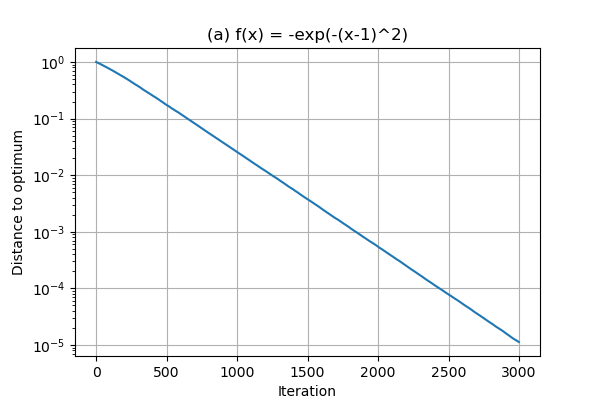

(b) Rosenbrock function — Final solution x = [-6.117407e+17  3.494232e+17]


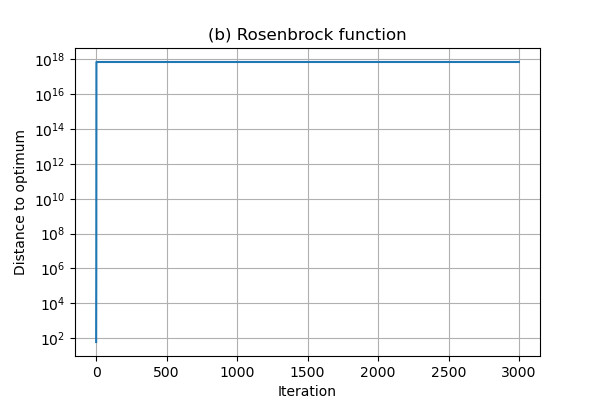

(c) Quadratic x^T A x + c^T x — Final solution x = [ 0.25 -0.25]


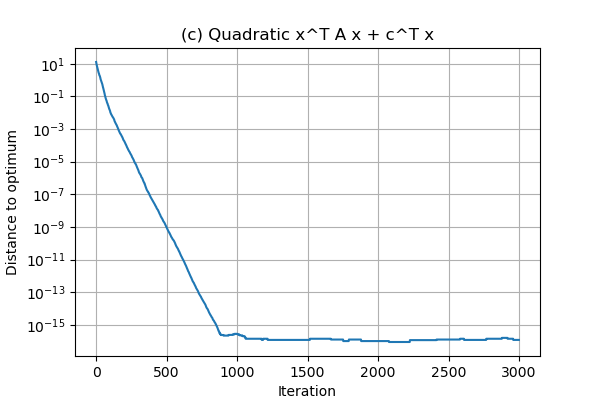

(d) Quadratic (solution is a line) — Final solution x = [-0.681763  0.681763  0.25    ]


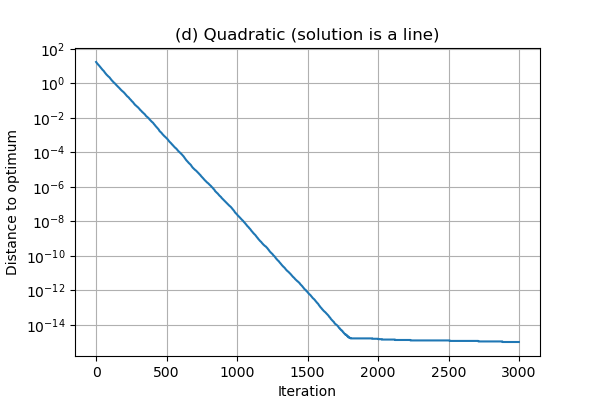

In [4]:
def run_and_plot(f, x0, dist_fn, title, max_iters=3000):
    dists, x_final = rs_optimize(f, x0, dist_fn, mu=1.0, alpha=0.01, N=10, max_iters=max_iters)
    print(f"{title} — Final solution x = {x_final}")
    plt.figure()
    plt.semilogy(dists)
    plt.title(title)
    plt.xlabel("Iteration")
    plt.ylabel("Distance to optimum")
    plt.show()

# Run the four questions in sequence
run_and_plot(f_a, x0_a, dist_a, "(a) f(x) = -exp(-(x-1)^2)")
run_and_plot(f_b, x0_b, dist_b, "(b) Rosenbrock function")
run_and_plot(f_c, x0_c, dist_c, "(c) Quadratic x^T A x + c^T x")
run_and_plot(f_d, x0_d, dist_d, "(d) Quadratic (solution is a line)")


### Comparison with Gradient Descent (GD)

Randomized Smoothing (RS) and Gradient Descent (GD) approach optimization from different angles. RS does not require explicit gradient formulas, while GD relies directly on the analytical gradient of the function. Because RS estimates gradients by sampling around the point, its trajectory during optimization tends to be noisier and slower. In contrast, GD follows a smoother path and usually converges more quickly when the gradient is available and the step size is chosen properly.

For smooth and well-behaved functions like the first and third problems, GD reaches the minimizer faster, whereas RS still converges but with a small amount of fluctuation caused by random sampling. In the Rosenbrock function, GD can diverge if the fixed step size is too large, due to the narrow curved valley of the function. RS behaves more robustly here because it does not move strictly in the steepest descent direction, although it takes more iterations to approach the minimum.

In the fourth function, where the solution is a whole set (a line) instead of a single point, both methods tend to move toward that solution set. GD settles on a specific point depending on the starting value, while RS hovers near the solution set because of its inherent randomness.

Overall, GD is faster and more efficient when gradients are accessible and the step size is chosen carefully. RS is more flexible and stable for problems where gradients are difficult to compute or the function is noisy, but this comes at the cost of slower convergence and more oscillation in the optimization path.


# Exercise 2

In [5]:
import sys, os, shutil, matplotlib as mpl
from pathlib import Path
import platform

print("Python exec:", sys.executable)
print("Platform:", platform.platform())
print("Matplotlib version:", mpl.__version__)

# Current environment path
env_bin = Path(sys.executable).parent
print("Environment bin path:", env_bin)

# Check if ffmpeg exists
ffmpeg_path = env_bin / "ffmpeg"
print("Expected ffmpeg path:", ffmpeg_path)
print("Exists?", ffmpeg_path.exists())

Python exec: /scratch/ww2781/conda_envs/reinforcement/bin/python
Platform: Linux-5.14.0-284.86.1.el9_2.x86_64-x86_64-with-glibc2.34
Matplotlib version: 3.10.6
Environment bin path: /scratch/ww2781/conda_envs/reinforcement/bin
Expected ffmpeg path: /scratch/ww2781/conda_envs/reinforcement/bin/ffmpeg
Exists? True


In [6]:
# Add reinforcement/bin to PATH
env_bin_str = str(Path(sys.executable).parent)
os.environ["PATH"] = env_bin_str + os.pathsep + os.environ.get("PATH", "")
print("PATH updated. ffmpeg found by shutil.which?:", shutil.which("ffmpeg"))

# Explicitly setting Matplotlib's animation writer
ff_path = shutil.which("ffmpeg") or str(env_bin / "ffmpeg")
mpl.rcParams["animation.writer"] = "ffmpeg"
mpl.rcParams["animation.ffmpeg_path"] = ff_path

print("Matplotlib animation.writer =", mpl.rcParams["animation.writer"])
print("Matplotlib animation.ffmpeg_path =", mpl.rcParams["animation.ffmpeg_path"])


PATH updated. ffmpeg found by shutil.which?: /scratch/ww2781/conda_envs/reinforcement/bin/ffmpeg
Matplotlib animation.writer = ffmpeg
Matplotlib animation.ffmpeg_path = /scratch/ww2781/conda_envs/reinforcement/bin/ffmpeg


In [7]:
from matplotlib.animation import writers
print("writers.is_available('ffmpeg') =", writers.is_available("ffmpeg"))


writers.is_available('ffmpeg') = True


In [8]:
import numpy as np
import manipulator

np.random.seed(0)
N_timesteps = 500
dt = 0.01
initial_state = np.zeros(3)
p_desired = np.array([2.0, 1.0])


In [9]:
def controller(state):
    """
    MPPI-based MPC controller.
    """
    # One-time initialization
    if not hasattr(controller, "initialized"):
        controller.initialized = True
        controller.Nh = 10           
        controller.K = 50            
        controller.alpha = 1.0
        controller.mu = 2.0          
        controller.lmbda = 0.1       
        controller.dt = dt
        controller.ubar = np.zeros((3, controller.Nh))  

    # Sampling noise: Shape (K, 3, Nh)
    eps = np.random.multivariate_normal(
        mean=np.zeros(3 * controller.Nh),
        cov=np.eye(3 * controller.Nh),
        size=controller.K
    ).reshape(controller.K, 3, controller.Nh)

    # Perform a rollout on each sample and calculate the cost.
    costs = np.zeros(controller.K)
    for k in range(controller.K):
        xk = state.copy()
        Jk = 0.0
        for n in range(controller.Nh):
            uk = controller.ubar[:, n] + controller.mu * eps[k, :, n]
            pk = manipulator.forward_kinematics(xk)
            Jk += np.sum((pk - p_desired) ** 2) + 0.01 * np.sum(uk ** 2)
            xk = manipulator.next_state(xk, uk, controller.dt)
        costs[k] = Jk

    # Calculate weights
    S = np.min(costs)
    w = np.exp(-(costs - S) / controller.lmbda)
    w_sum = np.sum(w) + 1e-12
    w /= w_sum

    # Weighted noise and updated nominal control sequence
    # weighted_eps  (3, Nh)
    weighted_eps = np.tensordot(w, eps, axes=(0, 0))
    delta_ubar = - controller.alpha * controller.lmbda / controller.mu * weighted_eps
    controller.ubar += delta_ubar

    # Output the current step control and perform a warm-start left shift.
    u_out = controller.ubar[:, 0].copy()
    controller.ubar = np.hstack([controller.ubar[:, 1:], np.zeros((3, 1))])

    return u_out


In [10]:
def reset_controller():

    for attr in list(vars(controller).keys()):
        delattr(controller, attr)

def run_once(target_xy, show_anim=True):

    global p_desired
    p_desired = np.array(target_xy, dtype=float)
    reset_controller()
    print(f"Running MPPI to target {tuple(p_desired)} ...")
    t, states, control = manipulator.simulate(initial_state, controller, N_timesteps)
    if show_anim:
        manipulator.animate_robot(states)

    return t, states, control


In [11]:
t1, x1, u1 = run_once((2, 1))
t2, x2, u2 = run_once((2, 2))
t3, x3, u3 = run_once((1, -2))


Running MPPI to target (np.float64(2.0), np.float64(1.0)) ...


Your browser does not support the video tag.

Running MPPI to target (np.float64(2.0), np.float64(2.0)) ...


Your browser does not support the video tag.

Running MPPI to target (np.float64(1.0), np.float64(-2.0)) ...


Your browser does not support the video tag.

## Do you always get the same result?

No, the results are not exactly the same across different runs.  
Each full simulation of 500 time steps produces a slightly different trajectory (states) and control sequence, even when using the same target position.

### Why?

The MPPI algorithm is stochastic by nature because it relies on Monte Carlo sampling at every control step.  
During each time step of the 500-step simulation, the `controller` function is called once, and it generates $K=50$ new random noise sequences
$\epsilon_k \sim \mathcal{N}(0, I)$ using `np.random.multivariate_normal`.

These random samples are used to form the candidate control sequences
$$
v_k \;=\; \bar{u} \;+\; \mu\,\epsilon_k .
$$

Since the noises $\epsilon_k$ are different each time, the resulting costs $S_k$, weights $w_k$, and control updates $\Delta \bar{u}$ also differ from one run to another. This randomness accumulates over all 500 steps, causing the overall state trajectory to be unique in every full run.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import manipulator

def compute_total_cost(states, controls, target):
    """Calculate the total cost of each complete simulation based on the problem definition."""
    total_cost = 0.0
    for n in range(controls.shape[1]):
        pk = manipulator.forward_kinematics(states[:, n])
        total_cost += np.sum((pk - target)**2) + 0.01 * np.sum(controls[:, n]**2)

    pk_final = manipulator.forward_kinematics(states[:, -1])
    total_cost += np.sum((pk_final - target)**2)
    return total_cost


In [14]:
def evaluate_target(target_xy, num_runs=10):
    """Repeatedly run MPPI for a single target point and return the total cost each time."""
    costs = []
    for i in range(num_runs):
        reset_controller()
        t, states, controls = manipulator.simulate(initial_state, controller, N_timesteps)
        total_cost = compute_total_cost(states, controls, np.array(target_xy))
        costs.append(total_cost)
        print(f"Run {i+1}/{num_runs} for target {target_xy}: total cost = {total_cost:.3f}")
    return np.array(costs)


In [ ]:
targets = [(2, 1), (2, 2), (1, -2)]
num_runs = 10

results = {}
for target in targets:
    print(f"\nEvaluating target {target} ...")
    results[target] = evaluate_target(target, num_runs=num_runs)

# Calculate the mean and variance
means = [np.mean(results[t]) for t in targets]
vars_ = [np.var(results[t]) for t in targets]



Evaluating target (2, 1) ...
Run 1/10 for target (2, 1): total cost = 970.025
Run 2/10 for target (2, 1): total cost = 1000.770
Run 3/10 for target (2, 1): total cost = 975.126
Run 4/10 for target (2, 1): total cost = 1026.372
Run 5/10 for target (2, 1): total cost = 997.258
Run 6/10 for target (2, 1): total cost = 957.455
Run 7/10 for target (2, 1): total cost = 1001.563
Run 8/10 for target (2, 1): total cost = 999.321
Run 9/10 for target (2, 1): total cost = 981.248
Run 10/10 for target (2, 1): total cost = 981.123

Evaluating target (2, 2) ...
Run 1/10 for target (2, 2): total cost = 947.301
Run 2/10 for target (2, 2): total cost = 910.164
Run 3/10 for target (2, 2): total cost = 928.952
Run 4/10 for target (2, 2): total cost = 951.888
Run 5/10 for target (2, 2): total cost = 970.432
Run 6/10 for target (2, 2): total cost = 951.431
Run 7/10 for target (2, 2): total cost = 911.116
Run 8/10 for target (2, 2): total cost = 934.161


In [ ]:
x_labels = [f"{t}" for t in targets]
x_pos = np.arange(len(targets))

plt.figure(figsize=(6,4))
plt.bar(x_pos, means, yerr=np.sqrt(vars_), capsize=6, alpha=0.7)
plt.xticks(x_pos, x_labels)
plt.ylabel("Average Total Cost ± Std")
plt.xlabel("Target Position")
plt.title("Average cost and its variance across 10 MPPI runs")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Exercise 3

In [5]:
# setup 
from collections import defaultdict

# State & control sets
STATES  = [-2, -1, 0,  1,  2]
CONTROLS = [-1, 0, 1]

# Saturation helper
def sat(x, lo=-2, hi=2):
    return max(lo, min(hi, x))

# Dynamics: x_{n+1} = sat(-x_n + 1 + u_n)
def f(x, u):
    return sat(-x + 1 + u)

# Stage cost and terminal cost
def g(x, u):    # per-stage cost
    return 2*abs(x) + abs(u)

def h_terminal(x):  # J_3(x) = x^2
    return x**2


In [6]:
# precompute transitions
next_state = {(x,u): f(x,u) for x in STATES for u in CONTROLS}

# quick visual check
for x in STATES:
    row = [f"x={x} -> "]
    for u in CONTROLS:
        row.append(f"u={u}: x'={next_state[(x,u)]}")
    print("  ".join(row))


x=-2 ->   u=-1: x'=2  u=0: x'=2  u=1: x'=2
x=-1 ->   u=-1: x'=1  u=0: x'=2  u=1: x'=2
x=0 ->   u=-1: x'=0  u=0: x'=1  u=1: x'=2
x=1 ->   u=-1: x'=-1  u=0: x'=0  u=1: x'=1
x=2 ->   u=-1: x'=-2  u=0: x'=-1  u=1: x'=0


In [7]:
# DP backward pass 
# Horizon: k = 0,1,2 with terminal at k=3
J = {3: {x: h_terminal(x) for x in STATES}}      # J_3(x)
PI = {}  

# Iterate k = 2, 1, 0
for k in [2, 1, 0]:
    J[k] = {}
    PI[k] = {}
    for x in STATES:
        # Enumerate all controls and pick the best
        candidates = []
        for u in CONTROLS:
            x_next = next_state[(x,u)]
            cost = g(x,u) + J[k+1][x_next]
            candidates.append((cost, u, x_next))
        # Select minimizer (tie-break: smaller |u| then smaller u)
        candidates.sort(key=lambda t: (t[0], abs(t[1]), t[1]))
        best_cost, best_u, best_next = candidates[0]
        J[k][x] = best_cost
        PI[k][x] = best_u


In [8]:
# pretty print 
def print_stage_table(k):
    print(f"\n=== Stage k={k} (cost-to-go J_{k}(x) and optimal control) ===")
    header = f"{'x':>4} | " + "  ".join([f"u={u:>2}" for u in CONTROLS]) + " ||  " + "best_u  J_k(x)"
    print(header)
    print("-"*len(header))
    for x in STATES:
        
        vals = []
        for u in CONTROLS:
            x_next = next_state[(x,u)]
            vals.append(g(x,u) + J[k+1][x_next])
        best_u = PI[k][x]
        print(f"{x:>4} | " + "  ".join([f"{v:>6}" for v in vals]) +
              f" || {best_u:>6}  {J[k][x]:>6}")

# Print k=2,1,0 tables
print_stage_table(2)
print_stage_table(1)
print_stage_table(0)



=== Stage k=2 (cost-to-go J_2(x) and optimal control) ===
   x | u=-1  u= 0  u= 1 ||  best_u  J_k(x)
------------------------------------------
  -2 |      9       8       9 ||      0       8
  -1 |      4       6       7 ||     -1       4
   0 |      1       1       5 ||      0       1
   1 |      4       2       4 ||      0       2
   2 |      9       5       5 ||      0       5

=== Stage k=1 (cost-to-go J_1(x) and optimal control) ===
   x | u=-1  u= 0  u= 1 ||  best_u  J_k(x)
------------------------------------------
  -2 |     10       9      10 ||      0       9
  -1 |      5       7       8 ||     -1       5
   0 |      2       2       6 ||      0       2
   1 |      7       3       5 ||      0       3
   2 |     13       8       6 ||      1       6

=== Stage k=0 (cost-to-go J_0(x) and optimal control) ===
   x | u=-1  u= 0  u= 1 ||  best_u  J_k(x)
------------------------------------------
  -2 |     11      10      11 ||      0      10
  -1 |      6       8       9 ||     

If x0 = 0:
- Optimal controls: [0, 0, 0]
- State trajectory: 0 -> 1 -> 0 -> 1
- Total cost: J* = 3

If x0 = -2:
- Optimal controls: [0, 1, 0]
- State trajectory: -2 -> 2 -> 0 -> 1
- Total cost: J* = 10

If x0 = 2:
- Optimal controls: [1, 0, 0]
- State trajectory: 2 -> 0 -> 1 -> 0
- Total cost: J* = 7
